# Exploratory Data Analysis and Machine Learning Problem Selection

<p align="center">
  <img src="../images/meme.png" width="450">
</p>


## Machine Learning Project

**Author:** Makarena Ampuero  

**Course:** Data Science  

**June 2026**


## Objective

Perform exploratory data analysis (EDA) on four different datasets to understand their structure, data quality, patterns, and potential Machine Learning applications.

The objective is to evaluate each dataset and identify the most suitable option for developing a supervised Machine Learning model.

The analysis includes:

- Data exploration and cleaning.
- Identification and treatment of missing values.
- Analysis of numerical and categorical variables.
- Data visualization and pattern detection.
- Evaluation of Machine Learning potential.

After comparing the four datasets, one will be selected for model development, optimization, and deployment.

## Import Libraries

The required Python libraries are imported for data manipulation, numerical analysis, and visualization.

In [61]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Dataset 1: Environmental Compliance Risk

## Dataset Overview

The Environmental Compliance dataset contains information about environmental projects, including compliance performance, project characteristics, documentation status, and historical non-compliance records.

The main objective of this dataset analysis is to evaluate whether these variables can be used to predict the environmental non-compliance risk level of a project.

The target variable for a potential Machine Learning classification model is:

**Target variable:** `non_compliance_risk`

**Problem type:** Supervised Classification

## 1. Dataset Loading

The dataset contains environmental compliance information related to different projects, including regulatory commitments, compliance status, historical non-compliance records, and risk classification.

In [62]:
df = pd.read_csv("../datasets/environmental_compliance.csv")

In [63]:
df.head()

,empresa,tipo_proyecto,region,numero_rca,año_rca,categoria_compromiso,frecuencia_reporte,responsable_area,dias_restantes,historial_incumplimientos,cantidad_documentos,presupuesto_asociado_usd,criticidad,cumplimiento_porcentaje,estado_avance,riesgo_incumplimiento
0,Colbun,Parque Eolico,Los Lagos,RCA-2308,2019,Reforestacion,Trimestral,Permisos,120,2,21.0,95808,Alta,77,En Proceso,Medio
1,Engie,Subestacion,Metropolitana,RCA-3986,2012,Ruido,Semestral,Operacion,285,1,22.0,40997,Baja,90,Completado,Bajo
2,Enel,Subestacion,Los Lagos,RCA-1386,2020,Flora y Fauna,Semestral,Medio Ambiente,353,3,17.0,88716,Alta,79,En Proceso,Medio
3,Engie,Linea de Transmision,Antofagasta,RCA-7131,2012,Reforestacion,Semestral,Territorio,236,1,5.0,115304,Baja,94,Completado,Bajo
4,Engie,Linea de Transmision,Biobio,RCA-4258,2021,Calidad de Aguas,Mensual,Construccion,115,2,6.0,69180,Media,66,En Proceso,Bajo


Este conjunto de datos contiene información relacionada con el cumplimiento ambiental de proyectos, considerando variables asociadas a permisos, compromisos ambientales, auditorías, fiscalizaciones y desempeño regulatorio.

El objetivo es analizar patrones asociados al cumplimiento ambiental y evaluar la posibilidad de construir un modelo predictivo de clasificación.

## 2. Initial Exploration

An initial inspection is performed to understand the dataset dimensions, variables, and data types.

In [64]:
df.shape

(3000, 16)

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   empresa                    3000 non-null   str    
 1   tipo_proyecto              3000 non-null   str    
 2   region                     3000 non-null   str    
 3   numero_rca                 3000 non-null   str    
 4   año_rca                    3000 non-null   int64  
 5   categoria_compromiso       3000 non-null   str    
 6   frecuencia_reporte         3000 non-null   str    
 7   responsable_area           2920 non-null   str    
 8   dias_restantes             3000 non-null   int64  
 9   historial_incumplimientos  3000 non-null   int64  
 10  cantidad_documentos        2920 non-null   float64
 11  presupuesto_asociado_usd   3000 non-null   int64  
 12  criticidad                 3000 non-null   str    
 13  cumplimiento_porcentaje    3000 non-null   int64  
 14  est

El conjunto de datos contiene registros de proyectos ambientales y variables asociadas a gestión regulatoria, seguimiento y desempeño ambiental.

Análisis de estructura del conjunto de datos

El dataset de cumplimiento ambiental contiene **3000 registros y 16 variables** asociadas a la gestión ambiental de proyectos.

Las variables presentan distintos tipos de información:

- **Variables categóricas (object): 10 columnas**
  - empresa
  - tipo_proyecto
  - region
  - numero_rca
  - categoria_compromiso
  - frecuencia_reporte
  - responsable_area
  - criticidad
  - estado_avance
  - riesgo_incumplimiento

- **Variables numéricas: 6 columnas**
  - año_rca
  - dias_restantes
  - historial_incumplimientos
  - cantidad_documentos
  - presupuesto_asociado_usd
  - cumplimiento_porcentaje

Se identifican valores faltantes en dos variables:

- responsable_area: 80 registros sin información.
- cantidad_documentos: 80 registros sin información.

Esto representa aproximadamente un 2,7% del total de datos, por lo que deberá evaluarse una estrategia de tratamiento antes de aplicar modelos predictivos.

La variable `riesgo_incumplimiento` corresponde a la variable objetivo, permitiendo formular un problema de clasificación supervisada.

### Descriptive Statistics

Descriptive statistics are calculated to analyze the central tendency, dispersion, and range of numerical variables.

In [66]:
df.describe()

,año_rca,dias_restantes,historial_incumplimientos,cantidad_documentos,presupuesto_asociado_usd,cumplimiento_porcentaje
count,3000.000000,3000.000000,3000.000000,2920.000000,3000.000000,3000.000000
mean,2017.464333,183.766333,1.207000,21.137671,75064.882667,71.514333
std,4.616763,105.176416,1.080065,18.489987,25094.708049,20.271460
min,2010.000000,5.000000,0.000000,1.000000,-15191.000000,0.000000
25%,2013.000000,90.000000,0.000000,10.000000,58100.250000,63.000000
50%,2017.000000,181.500000,1.000000,20.000000,75012.000000,75.000000
75%,2021.250000,278.250000,2.000000,29.000000,91639.500000,87.000000
max,2025.000000,364.000000,7.000000,180.000000,159727.000000,100.000000


Análisis estadístico descriptivo

El análisis estadístico de las variables numéricas muestra las siguientes características principales:

- **año_rca:**  
Las Resoluciones de Calificación Ambiental (RCA) presentes en el dataset corresponden al periodo entre 2010 y 2025. La media se encuentra alrededor del año 2017, mostrando proyectos con distintos niveles de antigüedad regulatoria.

- **dias_restantes:**  
Los proyectos presentan entre 5 y 364 días restantes asociados al seguimiento de compromisos ambientales. El promedio es de aproximadamente 184 días, indicando diferentes plazos de cumplimiento.

- **historial_incumplimientos:**  
La cantidad promedio de incumplimientos históricos es de 1,2 eventos por proyecto. La mayoría de los registros presenta entre 0 y 2 incumplimientos, aunque existen casos con hasta 7 eventos, considerados proyectos con mayor historial de riesgo.

- **cantidad_documentos:**  
Los proyectos poseen en promedio 21 documentos asociados a la gestión ambiental. Se observa un valor máximo de 180 documentos, lo que podría representar proyectos de mayor complejidad o posibles valores atípicos.

- **presupuesto_asociado_usd:**  
El presupuesto promedio asociado es cercano a 75.000 USD. Sin embargo, se identifica un valor mínimo negativo (-15.191 USD), lo cual corresponde a una inconsistencia de datos que deberá ser revisada durante la etapa de limpieza.

- **cumplimiento_porcentaje:**  
El porcentaje promedio de cumplimiento ambiental es de aproximadamente 71,5%. Los valores se encuentran entre 0% y 100%, rango esperado para esta variable.

En general, el dataset presenta variables con distintas escalas y algunos posibles valores extremos, por lo que será necesario evaluar tratamiento de outliers, limpieza de inconsistencias y normalización previo al modelamiento.

### Missing Values Detection

Missing values are identified to evaluate data quality and define appropriate cleaning strategies.

In [67]:
df.isnull().sum()

empresa                       0
tipo_proyecto                 0
region                        0
numero_rca                    0
año_rca                       0
categoria_compromiso          0
frecuencia_reporte            0
responsable_area             80
dias_restantes                0
historial_incumplimientos     0
cantidad_documentos          80
presupuesto_asociado_usd      0
criticidad                    0
cumplimiento_porcentaje       0
estado_avance                 0
riesgo_incumplimiento         0
dtype: int64

## 3. Data Cleaning

A copy of the original dataset is created before applying cleaning transformations.

Missing values are handled according to the type of variable:
- Categorical missing values are replaced with "Unknown".
- Numerical missing values are replaced using the median value to preserve the distribution and reduce the influence of extreme values.

In [68]:
# Load Environmental Compliance dataset

environmental_compliance = pd.read_csv(
    "../datasets/environmental_compliance.csv"
)

environmental_compliance.head()

,empresa,tipo_proyecto,region,numero_rca,año_rca,categoria_compromiso,frecuencia_reporte,responsable_area,dias_restantes,historial_incumplimientos,cantidad_documentos,presupuesto_asociado_usd,criticidad,cumplimiento_porcentaje,estado_avance,riesgo_incumplimiento
0,Colbun,Parque Eolico,Los Lagos,RCA-2308,2019,Reforestacion,Trimestral,Permisos,120,2,21.0,95808,Alta,77,En Proceso,Medio
1,Engie,Subestacion,Metropolitana,RCA-3986,2012,Ruido,Semestral,Operacion,285,1,22.0,40997,Baja,90,Completado,Bajo
2,Enel,Subestacion,Los Lagos,RCA-1386,2020,Flora y Fauna,Semestral,Medio Ambiente,353,3,17.0,88716,Alta,79,En Proceso,Medio
3,Engie,Linea de Transmision,Antofagasta,RCA-7131,2012,Reforestacion,Semestral,Territorio,236,1,5.0,115304,Baja,94,Completado,Bajo
4,Engie,Linea de Transmision,Biobio,RCA-4258,2021,Calidad de Aguas,Mensual,Construccion,115,2,6.0,69180,Media,66,En Proceso,Bajo


### Data Consistency Check

In [69]:
# Identify projects with negative associated budget values

environmental_compliance[
    environmental_compliance["presupuesto_asociado_usd"] < 0
]

,empresa,tipo_proyecto,region,numero_rca,año_rca,categoria_compromiso,frecuencia_reporte,responsable_area,dias_restantes,historial_incumplimientos,cantidad_documentos,presupuesto_asociado_usd,criticidad,cumplimiento_porcentaje,estado_avance,riesgo_incumplimiento
200,Transelec,Linea de Transmision,Atacama,RCA-7837,2014,Emisiones Atmosfericas,Mensual,Construccion,328,0,30.0,-5969,Alta,91,Completado,Medio
424,Transelec,Parque Solar,Coquimbo,RCA-2344,2021,Reforestacion,Mensual,Territorio,113,1,20.0,-3522,Baja,73,En Proceso,Bajo
551,CGE,Linea de Transmision,Biobio,RCA-4182,2011,Flora y Fauna,Mensual,Construccion,242,1,33.0,-5098,Alta,77,En Proceso,Medio
849,CGE,Subestacion,Coquimbo,RCA-1864,2022,Emisiones Atmosfericas,Semestral,Permisos,119,1,12.0,-8073,Media,89,Completado,Bajo
2270,Engie,Linea de Transmision,Coquimbo,RCA-7975,2021,Ruido,Mensual,NaN,23,1,24.0,-91,Alta,10,Pendiente,Alto
2981,AES Andes,Linea de Transmision,Los Lagos,RCA-9258,2022,Flora y Fauna,Mensual,Territorio,283,0,28.0,-15191,Media,82,Completado,Bajo


In [70]:
# Count negative values in associated budget

(
    environmental_compliance[
        "presupuesto_asociado_usd"
    ] < 0
).sum()

np.int64(6)

During the initial exploration, negative values were detected in the variable `presupuesto_asociado_usd`.

A total of 6 records contain negative budget values.

These values were identified as data inconsistencies because an environmental project budget cannot have a value below zero.

Therefore, these records require treatment before developing Machine Learning models.

### Missing Values Treatment

In [71]:
# Identify missing values in each variable

environmental_compliance.isnull().sum()

empresa                       0
tipo_proyecto                 0
region                        0
numero_rca                    0
año_rca                       0
categoria_compromiso          0
frecuencia_reporte            0
responsable_area             80
dias_restantes                0
historial_incumplimientos     0
cantidad_documentos          80
presupuesto_asociado_usd      0
criticidad                    0
cumplimiento_porcentaje       0
estado_avance                 0
riesgo_incumplimiento         0
dtype: int64

In [72]:
# Calculate missing value percentage by variable

missing_percentage = (
    environmental_compliance.isnull().sum()
    / len(environmental_compliance)
) * 100


missing_percentage[
    missing_percentage > 0
]

responsable_area       2.666667
cantidad_documentos    2.666667
dtype: float64

The missing values analysis shows that most variables in the dataset are complete.

Missing values were identified only in two variables:

- `responsable_area`: 80 missing records.
- `cantidad_documentos`: 80 missing records.

Considering that the dataset contains 3,000 records, missing values represent approximately 2.7% of the total data for each affected variable.

This low percentage indicates that the dataset has good overall quality. However, before developing Machine Learning models, missing values need to be handled to avoid errors during training.

Treatment strategy:

- `responsable_area`: Since this is a categorical variable, missing values will be replaced with `"Unknown"` to preserve the records while indicating unavailable information.

- `cantidad_documentos`: Since this is a numerical variable, missing values will be imputed using the median. The median was selected instead of the mean because this variable contains outliers, and the median is more robust to extreme values.

Rows were not removed because the missing percentage is low and the remaining information from each project may still contribute to predicting environmental compliance risk.

In [73]:
# Create a copy of the original dataset

clean_environmental_compliance = (
    environmental_compliance.copy()
)

In [74]:
# Replace missing categorical values with "Unknown"

clean_environmental_compliance[
    "responsable_area"
] = clean_environmental_compliance[
    "responsable_area"
].fillna(
    "Unknown"
)

In [75]:
# Replace missing numerical values using the median

clean_environmental_compliance[
    "cantidad_documentos"
] = clean_environmental_compliance[
    "cantidad_documentos"
].fillna(
    clean_environmental_compliance[
        "cantidad_documentos"
    ].median()
)

In [76]:
# Replace negative budget values with the median budget

budget_median = clean_environmental_compliance.loc[
    clean_environmental_compliance[
        "presupuesto_asociado_usd"
    ] >= 0,
    "presupuesto_asociado_usd"
].median()


clean_environmental_compliance.loc[
    clean_environmental_compliance[
        "presupuesto_asociado_usd"
    ] < 0,
    "presupuesto_asociado_usd"
] = budget_median

### Cleaning Verification

After applying the missing value treatment, the dataset is checked again to confirm that there are no remaining null values.

In [77]:
# Verify remaining missing values

clean_environmental_compliance.isnull().sum()

empresa                      0
tipo_proyecto                0
region                       0
numero_rca                   0
año_rca                      0
categoria_compromiso         0
frecuencia_reporte           0
responsable_area             0
dias_restantes               0
historial_incumplimientos    0
cantidad_documentos          0
presupuesto_asociado_usd     0
criticidad                   0
cumplimiento_porcentaje      0
estado_avance                0
riesgo_incumplimiento        0
dtype: int64

In [78]:
# Verify negative budget values after cleaning

(
    clean_environmental_compliance[
        "presupuesto_asociado_usd"
    ] < 0
).sum()

np.int64(0)

Initial Data Cleaning Results

After applying the cleaning process:

- No missing values remain in the dataset.
- Numerical inconsistencies were identified and corrected.
- All original records were preserved because missing values and inconsistencies represented a small percentage of the dataset.
- Categorical missing values were replaced with an `"Unknown"` category to retain information about unavailable data.
- Numerical missing values and inconsistent values were treated using the median due to the presence of outliers.
- The dataset is now prepared for further preprocessing steps and predictive modeling.

In [96]:
# Translate column names to English

clean_environmental_compliance = (
    clean_environmental_compliance.rename(
        columns={
            "empresa": "company",
            "tipo_proyecto": "project_type",
            "region": "region",
            "numero_rca": "rca_number",
            "año_rca": "rca_year",
            "categoria_compromiso": "commitment_category",
            "frecuencia_reporte": "report_frequency",
            "responsable_area": "responsible_area",
            "dias_restantes": "remaining_days",
            "historial_incumplimientos": "previous_non_compliance",
            "cantidad_documentos": "document_quantity",
            "presupuesto_asociado_usd": "associated_budget_usd",
            "criticidad": "criticality",
            "cumplimiento_porcentaje": "compliance_percentage",
            "estado_avance": "progress_status",
            "riesgo_incumplimiento": "non_compliance_risk"
        }
    )
)

In [97]:
# Translate categorical values

clean_environmental_compliance.replace(
    {
        "Bajo": "Low",
        "Medio": "Medium",
        "Alto": "High",

        "Alta": "High",
        "Media": "Medium",
        "Baja": "Low",

        "En Proceso": "In Progress",
        "Completado": "Completed",
        "Pendiente": "Pending",

        "Mensual": "Monthly",
        "Trimestral": "Quarterly",
        "Semestral": "Semiannual"
    },
    inplace=True
)

,company,project_type,region,rca_number,rca_year,commitment_category,report_frequency,responsible_area,remaining_days,previous_non_compliance,document_quantity,associated_budget_usd,criticality,compliance_percentage,progress_status,non_compliance_risk
0,Colbun,Parque Eolico,Los Lagos,RCA-2308,2019,Reforestacion,Quarterly,Permisos,120,2,21.0,95808,High,77,In Progress,Medium
1,Engie,Subestacion,Metropolitana,RCA-3986,2012,Ruido,Semiannual,Operacion,285,1,22.0,40997,Low,90,Completed,Low
2,Enel,Subestacion,Los Lagos,RCA-1386,2020,Flora y Fauna,Semiannual,Medio Ambiente,353,3,17.0,88716,High,79,In Progress,Medium
3,Engie,Linea de Transmision,Antofagasta,RCA-7131,2012,Reforestacion,Semiannual,Territorio,236,1,5.0,115304,Low,94,Completed,Low
4,Engie,Linea de Transmision,Biobio,RCA-4258,2021,Calidad de Aguas,Monthly,Construccion,115,2,6.0,69180,Medium,66,In Progress,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Enel,Linea de Transmision,Coquimbo,RCA-1949,2011,Calidad de Aguas,Anual,Territorio,134,2,25.0,83048,High,83,Completed,Medium
2996,Engie,Linea de Transmision,Metropolitana,RCA-4587,2012,Calidad de Aguas,Quarterly,Territorio,26,0,25.0,88713,High,13,Pending,High
2997,Engie,Linea de Transmision,Metropolitana,RCA-2111,2016,Flora y Fauna,Semiannual,Territorio,139,1,1.0,53470,High,88,Completed,Medium
2998,Engie,Linea de Transmision,Antofagasta,RCA-9367,2018,Ruido,Monthly,Permisos,24,3,22.0,70390,High,41,In Progress,High


In [98]:
clean_environmental_compliance.head()

,company,project_type,region,rca_number,rca_year,commitment_category,report_frequency,responsible_area,remaining_days,previous_non_compliance,document_quantity,associated_budget_usd,criticality,compliance_percentage,progress_status,non_compliance_risk
0,Colbun,Parque Eolico,Los Lagos,RCA-2308,2019,Reforestacion,Quarterly,Permisos,120,2,21.0,95808,High,77,In Progress,Medium
1,Engie,Subestacion,Metropolitana,RCA-3986,2012,Ruido,Semiannual,Operacion,285,1,22.0,40997,Low,90,Completed,Low
2,Enel,Subestacion,Los Lagos,RCA-1386,2020,Flora y Fauna,Semiannual,Medio Ambiente,353,3,17.0,88716,High,79,In Progress,Medium
3,Engie,Linea de Transmision,Antofagasta,RCA-7131,2012,Reforestacion,Semiannual,Territorio,236,1,5.0,115304,Low,94,Completed,Low
4,Engie,Linea de Transmision,Biobio,RCA-4258,2021,Calidad de Aguas,Monthly,Construccion,115,2,6.0,69180,Medium,66,In Progress,Low


## 4. Exploratory Data Analysis (EDA)

### Target Variable Analysis

- Risk Distribution

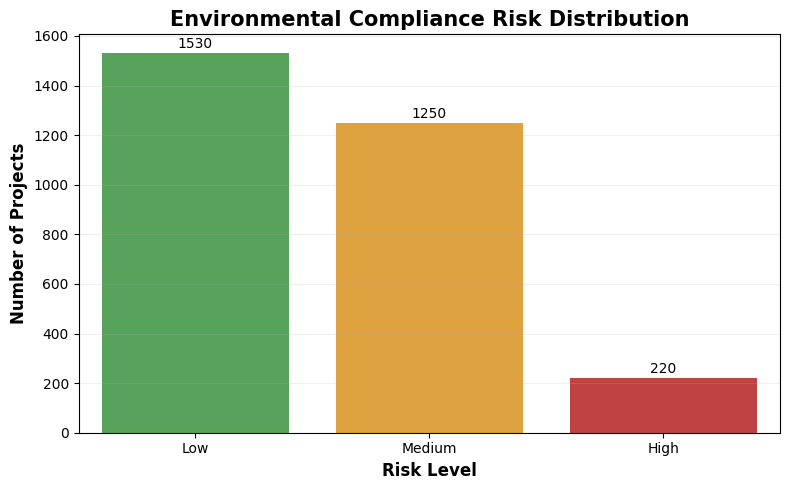

In [108]:
# Environmental compliance risk distribution

risk_order = [
    "Low",
    "Medium",
    "High"
]


risk_colors = {
    "Low": "#4CAF50",       # green
    "Medium": "#F9A825",    # amber
    "High": "#D32F2F"       # red
}


fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.countplot(
    data=clean_environmental_compliance,
    x="non_compliance_risk",
    hue="non_compliance_risk",
    order=risk_order,
    palette=risk_colors,
    legend=False,
    ax=ax
)


ax.set_title(
    "Environmental Compliance Risk Distribution",
    fontsize=15,
    fontweight="bold"
)


ax.set_xlabel(
    "Risk Level",
    fontsize=12,
    fontweight="bold"
)


ax.set_ylabel(
    "Number of Projects",
    fontsize=12,
    fontweight="bold"
)


# Add values on top of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=10,
        padding=1.5
    )


ax.grid(
    axis="y",
    alpha=0.2
)


plt.tight_layout()

plt.show()

The distribution of environmental non-compliance risk shows that most projects are classified as **Low** or **Medium Risk**, while a smaller proportion belongs to the **High Risk** category.

This indicates that although the majority of projects maintain acceptable compliance conditions, there is a specific group of projects with higher probability of environmental non-compliance that requires closer monitoring.

The presence of three clearly defined risk categories supports the development of a **supervised classification model**, where the objective is to predict the environmental risk level of a project based on its characteristics and compliance indicators.

### Numerical Variables Analysis

- Compliance Percentage Distribution

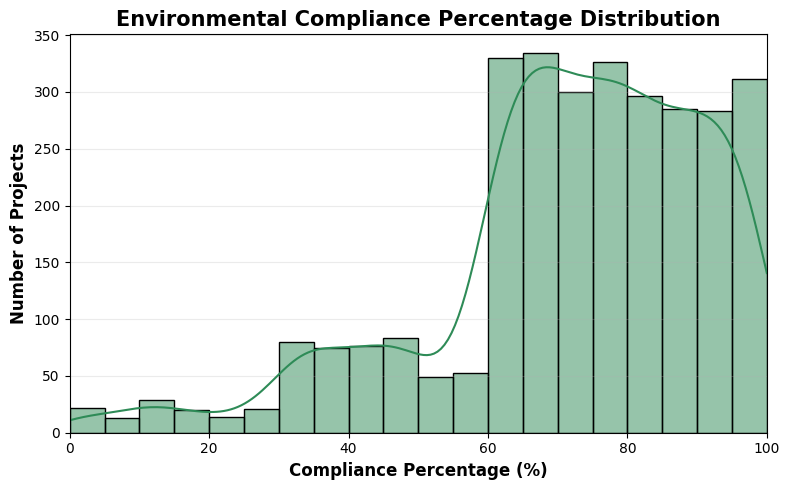

In [109]:
# Environmental compliance percentage distribution

fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.histplot(
    data=clean_environmental_compliance,
    x="compliance_percentage",
    bins=20,
    kde=True,
    color="#2E8B57",
    ax=ax
)


ax.set_title(
    "Environmental Compliance Percentage Distribution",
    fontsize=15,
    fontweight="bold"
)


ax.set_xlabel(
    "Compliance Percentage (%)",
    fontsize=12,
    fontweight="bold"
)


ax.set_ylabel(
    "Number of Projects",
    fontsize=12,
    fontweight="bold"
)


ax.set_xlim(
    0,
    100
)


ax.tick_params(
    axis="both",
    labelsize=10
)


ax.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()

plt.show()

**Main finding:**  
The distribution shows that most environmental projects present compliance percentages above **60%**, with a high concentration of projects reaching medium to high compliance levels.

**Environmental interpretation:**  
This suggests that most projects are actively fulfilling their environmental commitments. However, the presence of projects with lower compliance percentages indicates potential cases that may require additional monitoring, corrective actions, or regulatory follow-up.

**Machine Learning relevance:**  
Compliance percentage represents an important predictive variable because differences in fulfillment levels can help distinguish between **Low, Medium, and High environmental non-compliance risk categories**.

- Compliance by Risk Level

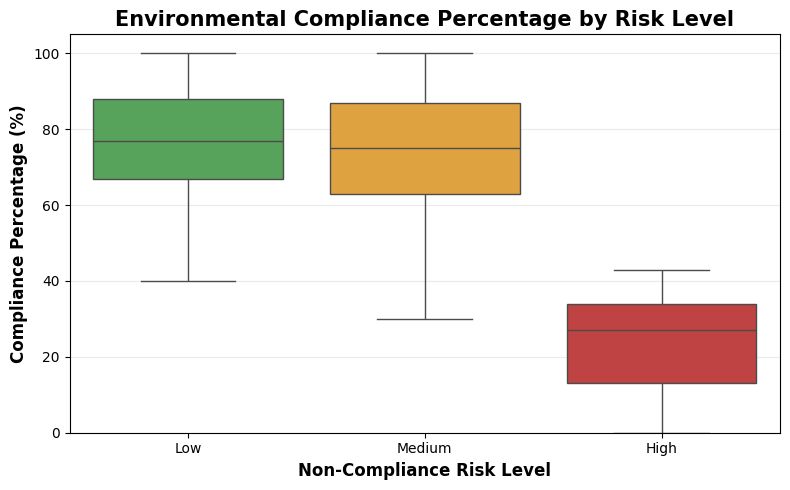

In [110]:
# Environmental compliance percentage by risk level

risk_order = [
    "Low",
    "Medium",
    "High"
]


risk_colors = {
    "Low": "#4CAF50",
    "Medium": "#F9A825",
    "High": "#D32F2F"
}


fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.boxplot(
    data=clean_environmental_compliance,
    x="non_compliance_risk",
    y="compliance_percentage",
    hue="non_compliance_risk",
    order=risk_order,
    palette=risk_colors,
    legend=False,
    ax=ax
)


ax.set_title(
    "Environmental Compliance Percentage by Risk Level",
    fontsize=15,
    fontweight="bold"
)


ax.set_xlabel(
    "Non-Compliance Risk Level",
    fontsize=12,
    fontweight="bold"
)


ax.set_ylabel(
    "Compliance Percentage (%)",
    fontsize=12,
    fontweight="bold"
)


ax.set_ylim(
    0,
    105
)


ax.tick_params(
    axis="both",
    labelsize=10
)


ax.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()

plt.show()

**Main finding:**  
The analysis shows a clear relationship between environmental compliance percentage and non-compliance risk classification.

Projects classified as **Low** and **Medium Risk** present higher compliance percentages, while **High Risk** projects show significantly lower compliance levels.

**Environmental interpretation:**  
High-risk projects have a considerably lower median compliance percentage, indicating weaker fulfillment of environmental commitments and a greater need for monitoring, preventive actions, and regulatory control.

The separation between risk categories suggests that compliance performance is strongly associated with environmental risk levels.

**Machine Learning relevance:**  
This variable provides strong predictive information for the classification model, as compliance behavior helps distinguish between different environmental non-compliance risk categories.

- Previous Non-Compliance Records

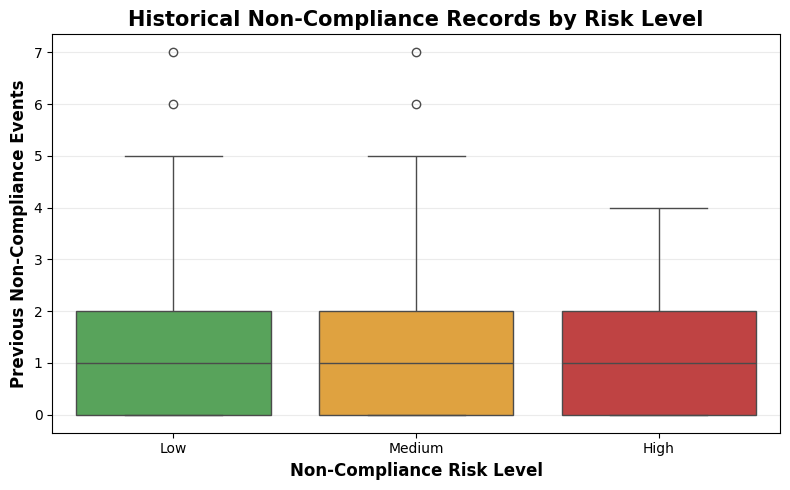

In [111]:
# Historical environmental non-compliance records by risk level

risk_order = [
    "Low",
    "Medium",
    "High"
]


risk_colors = {
    "Low": "#4CAF50",
    "Medium": "#F9A825",
    "High": "#D32F2F"
}


fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.boxplot(
    data=clean_environmental_compliance,
    x="non_compliance_risk",
    y="previous_non_compliance",
    hue="non_compliance_risk",
    order=risk_order,
    palette=risk_colors,
    legend=False,
    ax=ax
)


ax.set_title(
    "Historical Non-Compliance Records by Risk Level",
    fontsize=15,
    fontweight="bold"
)


ax.set_xlabel(
    "Non-Compliance Risk Level",
    fontsize=12,
    fontweight="bold"
)


ax.set_ylabel(
    "Previous Non-Compliance Events",
    fontsize=12,
    fontweight="bold"
)


ax.tick_params(
    axis="both",
    labelsize=10
)


ax.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()

plt.show()

**Main finding:**  
The distribution of previous environmental non-compliance events is relatively similar across the three risk categories.

Most projects present a low number of historical non-compliance records, although some isolated cases show higher values.

**Environmental interpretation:**  
The presence of outliers indicates that certain projects have experienced repeated compliance issues in the past, which may require additional monitoring and preventive actions.

However, historical non-compliance alone does not completely explain the environmental risk classification and should be analyzed together with other compliance indicators.

**Machine Learning relevance:**  
Previous non-compliance records can provide complementary information to the predictive model, but risk classification is likely influenced by multiple variables such as compliance percentage, project criticality, deadlines, and project characteristics.

### Categorical Variables Analysis

- Criticality and Risk Relationship

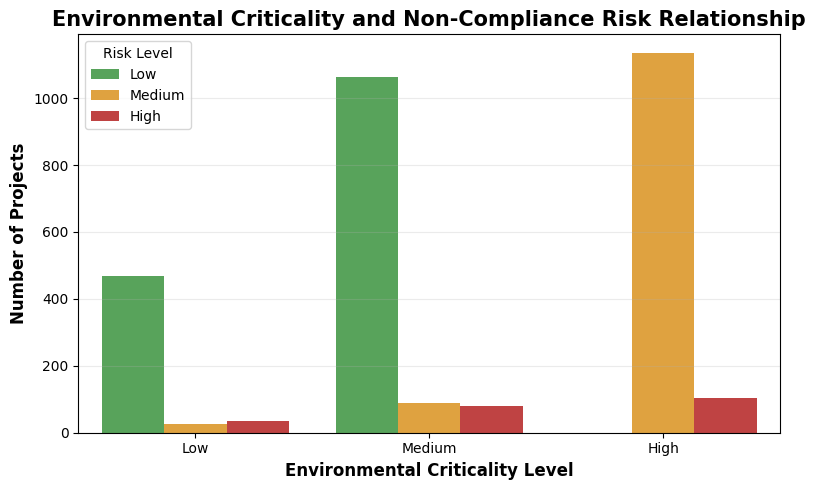

In [112]:
# Environmental criticality and non-compliance risk relationship

risk_order = [
    "Low",
    "Medium",
    "High"
]


risk_colors = {
    "Low": "#4CAF50",
    "Medium": "#F9A825",
    "High": "#D32F2F"
}


criticality_order = [
    "Low",
    "Medium",
    "High"
]


fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.countplot(
    data=clean_environmental_compliance,
    x="criticality",
    hue="non_compliance_risk",
    order=criticality_order,
    hue_order=risk_order,
    palette=risk_colors,
    ax=ax
)


ax.set_title(
    "Environmental Criticality and Non-Compliance Risk Relationship",
    fontsize=15,
    fontweight="bold"
)


ax.set_xlabel(
    "Environmental Criticality Level",
    fontsize=12,
    fontweight="bold"
)


ax.set_ylabel(
    "Number of Projects",
    fontsize=12,
    fontweight="bold"
)


ax.legend(
    title="Risk Level"
)


ax.tick_params(
    axis="both",
    labelsize=10
)


ax.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()

plt.show()

**Main finding:**  
The analysis shows a strong relationship between environmental criticality level and non-compliance risk classification.

Projects with **Low** and **Medium Criticality** are mainly associated with **Low Risk**, while projects classified as **High Criticality** present a considerable increase in **Medium and High Risk categories**.

**Environmental interpretation:**  
Higher criticality projects are more likely to require additional environmental supervision due to greater operational complexity, regulatory requirements, or potential environmental impacts.

This suggests that criticality level is an important factor when prioritizing monitoring efforts and preventive compliance strategies.

**Machine Learning relevance:**  
Environmental criticality provides highly relevant predictive information for the classification model.

The clear differences between criticality groups help the model distinguish risk patterns and improve environmental non-compliance prediction.

- Project Type Analysis

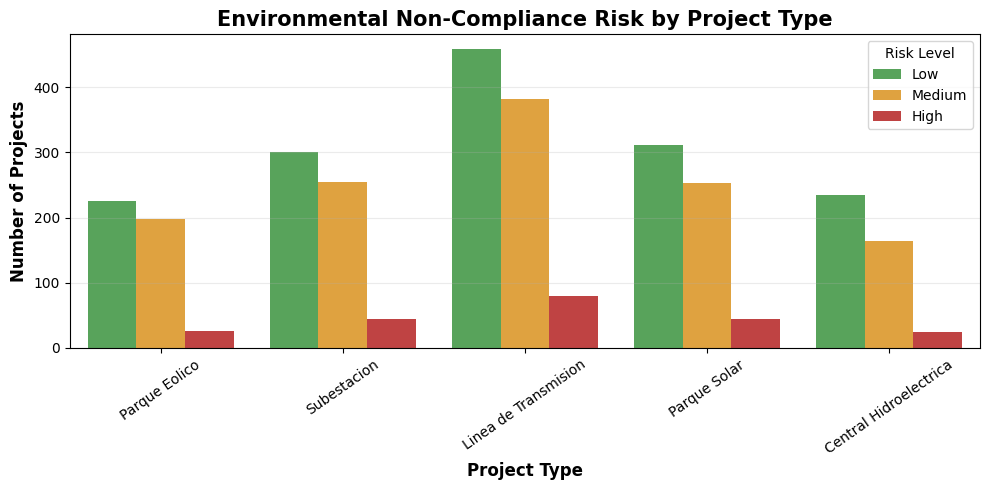

In [113]:
# Environmental non-compliance risk by project type

risk_order = [
    "Low",
    "Medium",
    "High"
]


risk_colors = {
    "Low": "#4CAF50",
    "Medium": "#F9A825",
    "High": "#D32F2F"
}


fig, ax = plt.subplots(
    figsize=(10, 5)
)


sns.countplot(
    data=clean_environmental_compliance,
    x="project_type",
    hue="non_compliance_risk",
    hue_order=risk_order,
    palette=risk_colors,
    ax=ax
)


ax.set_title(
    "Environmental Non-Compliance Risk by Project Type",
    fontsize=15,
    fontweight="bold"
)


ax.set_xlabel(
    "Project Type",
    fontsize=12,
    fontweight="bold"
)


ax.set_ylabel(
    "Number of Projects",
    fontsize=12,
    fontweight="bold"
)


ax.tick_params(
    axis="x",
    rotation=35,
    labelsize=10
)


ax.tick_params(
    axis="y",
    labelsize=10
)


ax.legend(
    title="Risk Level"
)


ax.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()

plt.show()

**Main finding:**  
The analysis shows that environmental non-compliance risk is present across all project types, with different distributions depending on project category.

Transmission Line projects represent the largest group in the dataset and also contain the highest number of Medium and High Risk cases.

**Environmental interpretation:**  
The presence of higher risk cases in certain project types may be related to differences in operational complexity, regulatory requirements, geographical extension, or the number of environmental commitments associated with each project.

Large infrastructure projects, such as transmission lines, often require continuous environmental monitoring due to their interaction with multiple areas and stakeholders.

**Machine Learning relevance:**  
Project type provides contextual information that may help the classification model identify environmental risk patterns.

However, risk prediction should consider multiple variables together, including project criticality, compliance percentage, and historical compliance performance.

- Outlier Analysis

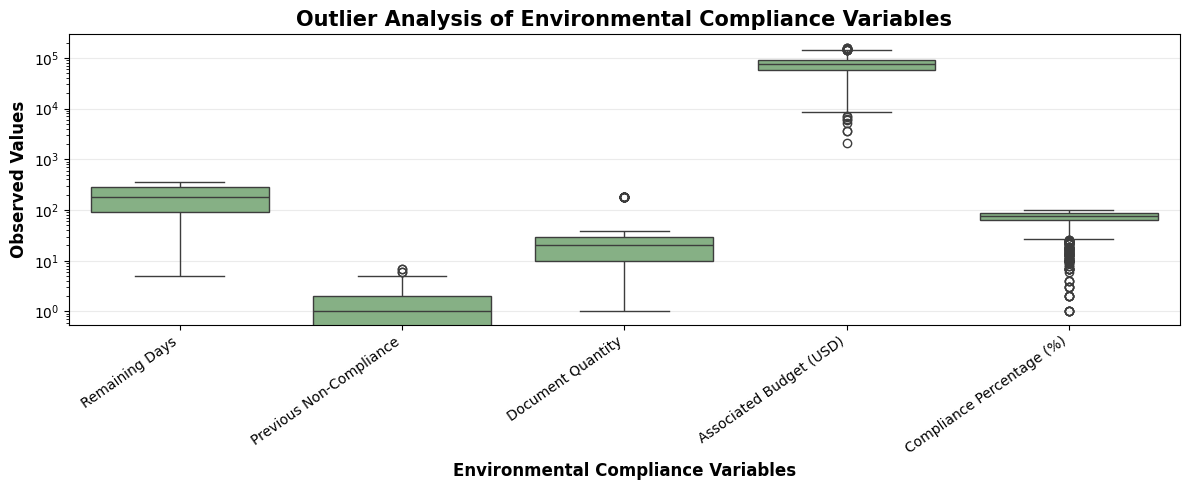

In [117]:
# Outlier analysis for numerical environmental compliance variables

outlier_variables = [
    "remaining_days",
    "previous_non_compliance",
    "document_quantity",
    "associated_budget_usd",
    "compliance_percentage"
]


variable_labels = [
    "Remaining Days",
    "Previous Non-Compliance",
    "Document Quantity",
    "Associated Budget (USD)",
    "Compliance Percentage (%)"
]


fig, ax = plt.subplots(
    figsize=(12, 5)
)


sns.boxplot(
    data=clean_environmental_compliance[
        outlier_variables
    ],
    color="#7FB77E",
    ax=ax
)


ax.set_title(
    "Outlier Analysis of Environmental Compliance Variables",
    fontsize=15,
    fontweight="bold"
)


ax.set_xlabel(
    "Environmental Compliance Variables",
    fontsize=12,
    fontweight="bold"
)


ax.set_ylabel(
    "Observed Values",
    fontsize=12,
    fontweight="bold"
)


ax.set_xticks(
    range(
        len(variable_labels)
    )
)

ax.set_xticklabels(
    variable_labels,
    rotation=35,
    ha="right"
)


ax.tick_params(
    axis="y",
    labelsize=10
)


ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_yscale(
    "log"
)

plt.tight_layout()

plt.show()

**Main finding:**  
The outlier analysis shows variability across several numerical environmental compliance variables. The use of a logarithmic scale allows variables with different magnitudes to be compared more effectively.

**Environmental interpretation:**  
Some variables, especially **Associated Budget (USD)**, present extreme values due to differences in project size, complexity, and environmental management requirements.

Additionally, variations in documents, deadlines, and compliance percentages reflect the diversity of environmental projects included in the dataset.

These values were preserved because they represent realistic project conditions rather than data quality issues.

**Machine Learning relevance:**  
The presence of different value ranges and extreme observations highlights the importance of applying preprocessing techniques before model training.

Numerical scaling methods such as **StandardScaler** will be included in the Machine Learning pipeline to reduce scale differences and improve model performance.

- Correlation Analysis

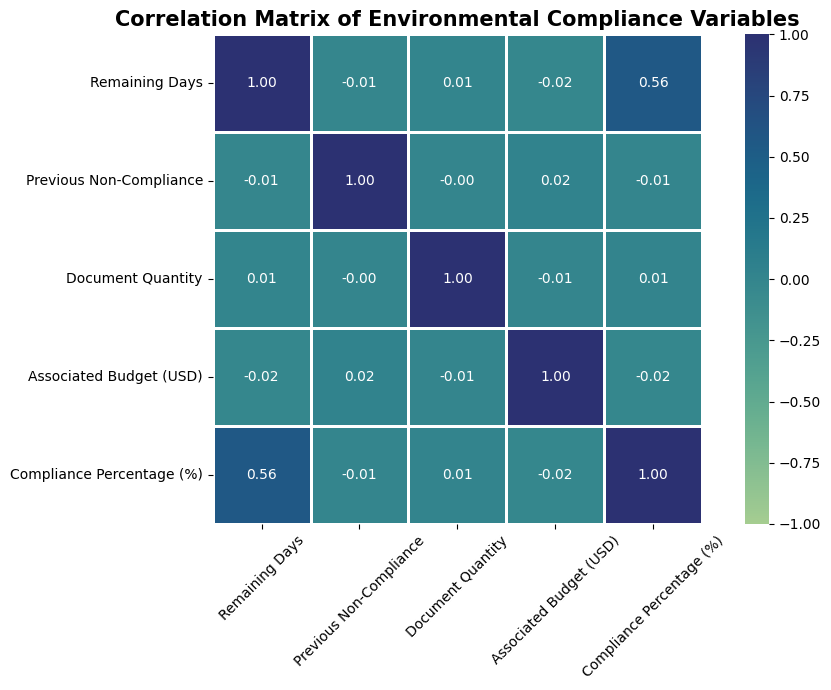

In [ ]:
# Correlation analysis of numerical environmental compliance variables

correlation_variables = [
    "remaining_days",
    "previous_non_compliance",
    "document_quantity",
    "associated_budget_usd",
    "compliance_percentage"
]


correlation_labels = [
    "Remaining Days",
    "Previous Non-Compliance",
    "Document Quantity",
    "Associated Budget (USD)",
    "Compliance Percentage (%)"
]


correlation_matrix = (
    clean_environmental_compliance[
        correlation_variables
    ]
    .corr()
)


# Rename variables only for visualization

correlation_matrix.columns = (
    correlation_labels
)

correlation_matrix.index = (
    correlation_labels
)


fig, ax = plt.subplots(
    figsize=(10, 7)
)


sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="crest",
    linewidths=1,
    linecolor="white",
    square=True,
    vmin=-1,
    vmax=1,
    center=0,
    ax=ax
)

ax.set_title(
    "Correlation Matrix of Environmental Compliance Variables",
    fontsize=15,
    fontweight="bold"
)

ax.tick_params(
    axis="x",
    rotation=45,
    labelsize=10
)

ax.tick_params(
    axis="y",
    rotation=0,
    labelsize=10
)

plt.tight_layout()

plt.show()

**Main finding:**  
The correlation matrix shows that most numerical environmental compliance variables have weak linear relationships, suggesting that each variable provides different information about project behavior.

A moderate positive correlation (**0.56**) was observed between **Remaining Days** and **Compliance Percentage**.

**Environmental interpretation:**  
Projects with more remaining time tend to present higher compliance percentages. This may be related to better planning, earlier follow-up stages, or greater availability of time to complete environmental commitments.

The weak correlations among the remaining variables suggest that environmental compliance risk is influenced by multiple factors rather than a single numerical indicator.

**Machine Learning relevance:**  
The absence of strong correlations between predictors reduces the risk of multicollinearity.

Combining variables related to deadlines, compliance performance, documentation, budget, and historical records allows the model to capture different aspects of environmental risk prediction.

# 5. Dataset Evaluation Summary

The exploratory data analysis showed that the environmental compliance dataset contains suitable characteristics to address a Machine Learning classification problem.

The selected problem is the **prediction of environmental non-compliance risk**, using **non_compliance_risk** as the target variable.

The dataset contains:

- **3,000 environmental project records.**
- Relevant numerical and categorical variables related to environmental management.
- A low percentage of missing values, which were treated during the initial data cleaning process.
- Meaningful relationships between compliance indicators and environmental risk categories.
- Predictive variables associated with compliance performance, project criticality, deadlines, and historical records.

The main challenges identified for the next stages are:

- Encoding categorical variables using appropriate transformation techniques.
- Scaling numerical variables due to different ranges and magnitudes.
- Applying preprocessing pipelines to ensure reproducibility.
- Training and comparing multiple Machine Learning classification algorithms.
- Optimizing model performance through hyperparameter tuning techniques.